# IS 6482 - Week 4 — Ensemble Methods

**Author:** Varun Gupta

**Date:** 1 March, 2026

**Models:**
1. Bagging
2. Random Forest
3. Gradient Boosting
4. AdaBoost
5. (Optional) XGBoost

**Datasets:** Telco customer churn

**Outline:**
- Data load + minimal cleaning
- `Pipeline` + `ColumnTransformer` + `OneHotEncoder` (new!)
- Baseline Decision Tree
- Bagging vs Random Forest (for variance reduction)
- Gradient Boosting (for bias reduction)
- Feature importance: impurity importance, permutation importance


## (0) Import libraries


In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

RANDOM_STATE = 42

## (1) Load the Telco churn dataset


In [15]:
# If you have a local copy, you can replace this with: df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
telco_url = "https://raw.githubusercontent.com/plotly/datasets/master/telco-customer-churn-by-IBM.csv"
df = pd.read_csv(telco_url)

df.shape

(7043, 21)

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## (2) Minimal cleaning

Common quirks in this dataset:
- `customerID` is an ID column → drop it.
- `TotalCharges` loads as text → convert to numeric (coerce errors to NaN).
- Drop rows where `TotalCharges` is NaN
- Separate features (`X`) and labels (`y`)
- `Churn` is Yes/No → convert to 1/0.


In [17]:
# Drop ID column
if "customerID" in df.columns:
  df = df.drop(columns=["customerID"])

# Convert TotalCharges to numeric (blank strings become NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.dropna(inplace=True)  # drop rows with empty TotalCharges

# Target
y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["Churn"])

# Quick check
y.value_counts(normalize=True).rename("Churn rate")

Churn
0    0.734215
1    0.265785
Name: Churn rate, dtype: float64

## (3) Train/test split (stratified)

We stratify so the churn rate is similar in train and test.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state = RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape

display(y_train.value_counts(normalize=True))
display(y_test.value_counts(normalize=True))

Churn
0    0.734168
1    0.265832
Name: proportion, dtype: float64

Churn
0    0.734357
1    0.265643
Name: proportion, dtype: float64

## (4) Preprocessing with `ColumnTransformer` + `Pipeline` (new concept)

We will setup a Machine Learning pipeline for Data -> Data Transformation -> Model:

Why do this?
- Makes it easy to swap models in/out while keeping preprocessing identical.
- Makes **permutation importance** much easier and more correct.

The Data Transformation we will perform is One-hot encoding of categorical columns.
To prevent **data leakage** the one-hot encoding will be based on training set (that is encoding does not see levels for a categorical feature that are in test but not train).
At test time we will ignore unseen categories.

In practice you can use Data Transformation to also
- Impute numeric columns (e.g. with median)
- Impute categorical columns (e.g., with most-frequent)
- Normalize numeric columns





In [19]:
# Identify categorical and numeric columns
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

# OneHotEncoder
# (ignore unseen categories at test time)
# Do not produce a sparse output (which require special algorithms)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# ColumnTransformer: OHE for categorical, passthrough for numeric
# verbose_feature_names_out=False gives cleaner names like "gender_Female"
# "num" and "cat" are names that we are defining for the transformations
preprocess = ColumnTransformer(
            transformers=[
                            ("cat", ohe, cat_cols),
                            ("num", "passthrough", num_cols),
                            ],
                    remainder="drop",
                    verbose_feature_names_out=False,
                )

preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## (5) Helper functions (evaluation + feature importance)

We will reuse the same evaluation function across models:
- Accuracy
- F1 (for churn=1)
- AUC
- Confusion matrix
- Classification report


In [20]:
# Helper function to Evaluate a fitting pipeline
def evaluate_classifier(pipe, X_train, X_test, y_train, y_test, model_name="model"):
    """Fit + evaluate a binary classifier pipeline."""
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 (churn=1): {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn (0)", "Churn (1)"])
    disp.plot(values_format="d")
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

    # Optional: ROC-AUC if predict_proba exists
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f"ROC-AUC: {auc:.4f}")
    else:
        auc = NaN

    return {"model": model_name, "accuracy": acc, "f1": f1, "auc" : auc}

## (6) Baseline model: Decision Tree (what you already know)

This anchors the lesson: ensembles are “many trees combined” to improve performance and stability.


In [21]:
tree_clf = DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=8,
        )

pipe_tree = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", tree_clf),
        ])

pipe_tree

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont


=== Decision Tree ===
Accuracy: 0.7793
F1 (churn=1): 0.5488


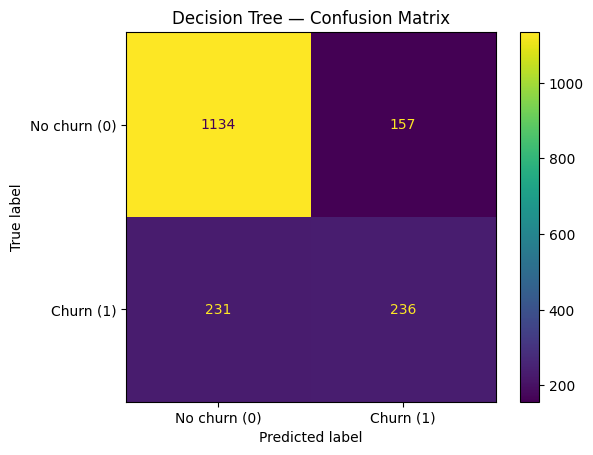


Classification report:
              precision    recall  f1-score   support

    No churn       0.83      0.88      0.85      1291
       Churn       0.60      0.51      0.55       467

    accuracy                           0.78      1758
   macro avg       0.72      0.69      0.70      1758
weighted avg       0.77      0.78      0.77      1758

ROC-AUC: 0.7895


In [22]:
pipe_tree.fit(X_train, y_train)
y_pred = pipe_tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n=== Decision Tree ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1 (churn=1): {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn (0)", "Churn (1)"])
disp.plot(values_format="d")
plt.title("Decision Tree — Confusion Matrix")
plt.show()

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))

# Note: ROC-AUC requires the predict_proba function to be available
y_proba = pipe_tree.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")
result_dict = {"model": "Decision Tree", "accuracy": acc, "f1": f1, "auc" : auc}

results = []
results.append(result_dict)


=== Decision Tree ===
Accuracy: 0.7793
F1 (churn=1): 0.5488


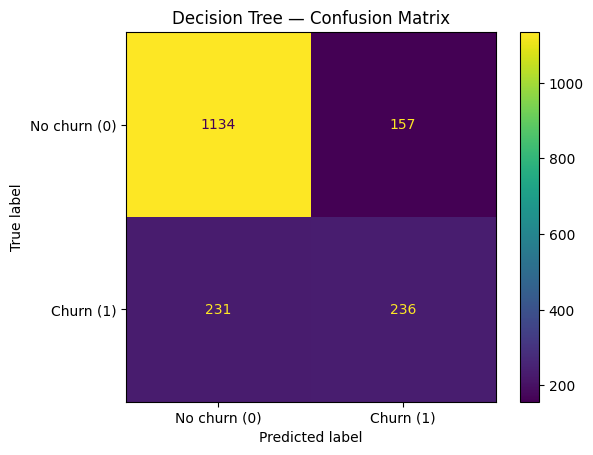


Classification report:
              precision    recall  f1-score   support

    No churn       0.83      0.88      0.85      1291
       Churn       0.60      0.51      0.55       467

    accuracy                           0.78      1758
   macro avg       0.72      0.69      0.70      1758
weighted avg       0.77      0.78      0.77      1758

ROC-AUC: 0.7895


In [23]:
results = []
results.append(evaluate_classifier(pipe_tree, X_train, X_test, y_train, y_test, model_name="Decision Tree"))

## (7) Bagging (Bootstrap Aggregating)

Idea:
- Fit many trees on bootstrap samples (different “views” of the training data)
- Combine predictions (vote/average)
- **Main benefit:** reduces variance (stabilizes a wiggly model like a tree)



=== Bagging (Trees) ===
Accuracy: 0.7935
F1 (churn=1): 0.5724


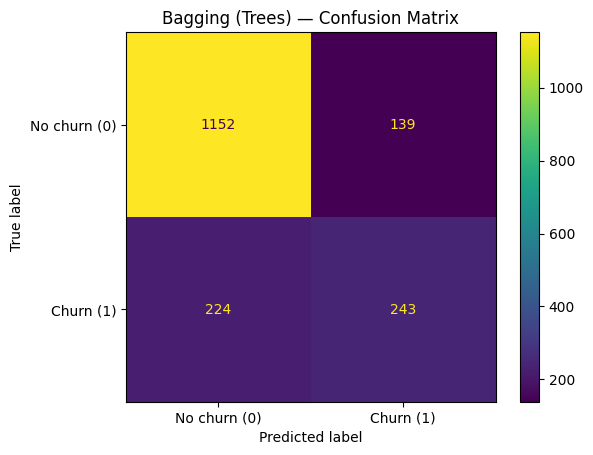


Classification report:
              precision    recall  f1-score   support

    No churn       0.84      0.89      0.86      1291
       Churn       0.64      0.52      0.57       467

    accuracy                           0.79      1758
   macro avg       0.74      0.71      0.72      1758
weighted avg       0.78      0.79      0.79      1758

ROC-AUC: 0.8119
Bagging OOB score: 0.7851725445582101


In [24]:
# BaggingClassifier

bag_model = BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                n_estimators=200,
                bootstrap=True,
                oob_score=True,
                n_jobs=-1,
                random_state=RANDOM_STATE,
                )

pipe_bag = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", bag_model),
            ])
pipe_bag

results.append(evaluate_classifier(pipe_bag, X_train, X_test, y_train, y_test, model_name="Bagging (Trees)"))

# Out-of-bag score (fast-ish internal validation estimate)
print("Bagging OOB score:", pipe_bag.named_steps["model"].oob_score_)

## (8) Random Forest

Random Forest = Bagging + extra randomness:
- still uses bootstrap samples
- **and** at each split, only considers a random subset of features (`max_features` / mtry)

This decorrelates trees → stronger variance reduction.



=== Random Forest ===
Accuracy: 0.7838
F1 (churn=1): 0.5444


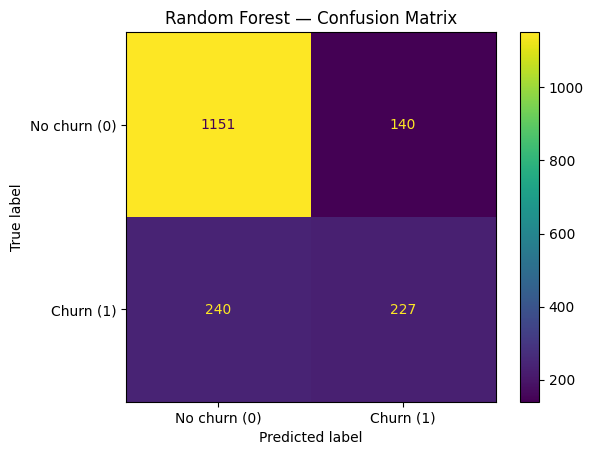


Classification report:
              precision    recall  f1-score   support

    No churn       0.83      0.89      0.86      1291
       Churn       0.62      0.49      0.54       467

    accuracy                           0.78      1758
   macro avg       0.72      0.69      0.70      1758
weighted avg       0.77      0.78      0.77      1758

ROC-AUC: 0.8146
Random Forest OOB score: 0.79161926431551


In [25]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=True,
    max_features="sqrt",   # default in sklearn for classification
)

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf_model),
])

results.append(evaluate_classifier(pipe_rf, X_train, X_test, y_train, y_test, model_name="Random Forest"))

print("Random Forest OOB score:", pipe_rf.named_steps["model"].oob_score_)

## (9) Gradient Boosting (sequential trees)

Boosting builds trees **sequentially**:
- each new tree tries to correct errors made by the previous ensemble
- **Main benefit:** reduces bias (can fit complex patterns)

Key knobs:
- `n_estimators` = number of trees (stages)
- `learning_rate` = how much to shrink the output of the new tree before adding to ensemble (smaller = slower but often better generalization)



=== Gradient Boosting ===
Accuracy: 0.7947
F1 (churn=1): 0.5728


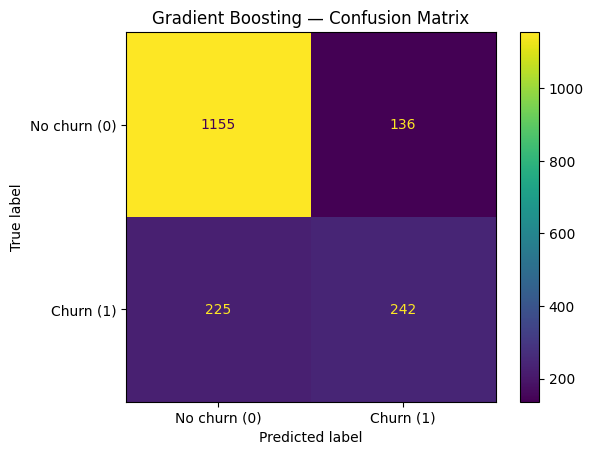


Classification report:
              precision    recall  f1-score   support

    No churn       0.84      0.89      0.86      1291
       Churn       0.64      0.52      0.57       467

    accuracy                           0.79      1758
   macro avg       0.74      0.71      0.72      1758
weighted avg       0.78      0.79      0.79      1758

ROC-AUC: 0.8393


In [26]:
gb_model = GradientBoostingClassifier(
    random_state=RANDOM_STATE,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
)

pipe_gb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", gb_model),
])

results.append(evaluate_classifier(pipe_gb, X_train, X_test, y_train, y_test, model_name="Gradient Boosting"))

## (10) [OPTIONAL] AdaBoost

AdaBoost is also sequential, but it reweighs examples so the model focuses on “hard-to-classify” points

Here we will use **stumps** (depth=1 trees) as our base classifier.



=== AdaBoost (Stumps) ===
Accuracy: 0.7958
F1 (churn=1): 0.5791


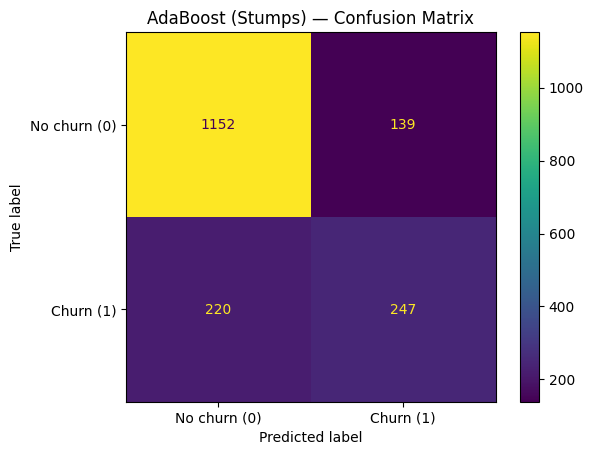


Classification report:
              precision    recall  f1-score   support

    No churn       0.84      0.89      0.87      1291
       Churn       0.64      0.53      0.58       467

    accuracy                           0.80      1758
   macro avg       0.74      0.71      0.72      1758
weighted avg       0.79      0.80      0.79      1758

ROC-AUC: 0.8381


In [27]:
ada_model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
            n_estimators=300,
            learning_rate=0.5,
            random_state=RANDOM_STATE,
            )

pipe_ada = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ada_model),
    ])

results.append(evaluate_classifier(pipe_ada, X_train, X_test, y_train, y_test, model_name="AdaBoost (Stumps)"))

## (11) Comparison across the 5 methods

In [28]:
pd.DataFrame(results).sort_values(by="auc", ascending=False)

,model,accuracy,f1,auc
3,Gradient Boosting,0.794653,0.572781,0.839301
4,AdaBoost (Stumps),0.795791,0.579132,0.838081
2,Random Forest,0.783845,0.544365,0.814556
1,Bagging (Trees),0.793515,0.572438,0.811901
0,Decision Tree,0.779295,0.548837,0.789472


## (12) Feature importance

Ensemble methods are not interpretable (unlike shallow decisio trees). We will see **two** approaches for extracting how important each feature for the predictions of the ensemble.

### A) Impurity-based importance / Mean Decrease in Impurity (MDI) -- Fast, already computed while trees are built out, and available directly from tree ensembles
- Available as `feature_importances_` for many tree models
- But can be **biased** toward high-cardinality features and can be misleading when models overfit
- Computed on Training set

### B) Permutation importance (model-agnostic)
- Shuffle one feature column and see how the score drops
- Can be computed on a **held-out** set

We will compute both and discuss differences.


In [29]:
# Helper function to aggregate importance of one-hot-encoded features based on original categorical column
def aggregate_ohe_importance_to_original(feature_names, importances):
    """Aggregate one-hot feature importances back to the original column name.

    Assumes OHE feature names look like: OriginalCol_Category.
      e.g. OnlineSecurity_No
      because we set verbose_feature_names_out=False
    If we had set verbose_feature_names_out=True our columns name would look like
      cat__OnlineSecurity_Yes, num__TotalCharges
    """
    s = pd.Series(importances, index=feature_names)

    def base_name(name: str) -> str:
        # If the feature is one-hot encoded, take the part before the first underscore

        return name.split("_", 1)[0]

    grouped = s.groupby([base_name(n) for n in s.index]).sum().sort_values(ascending=False)
    return grouped

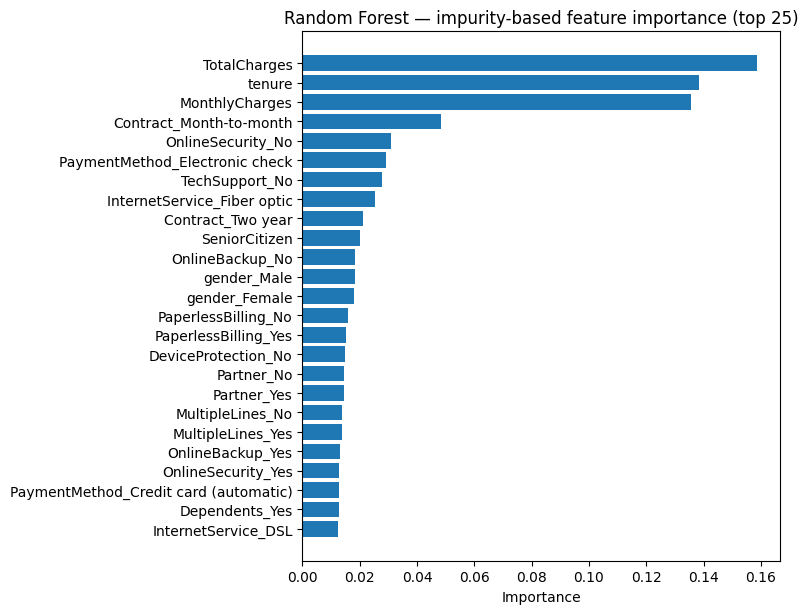

One-hot importances aggregated back to original columns:


TotalCharges        0.158750
tenure              0.138524
MonthlyCharges      0.135453
Contract            0.079867
PaymentMethod       0.064475
OnlineSecurity      0.046236
TechSupport         0.043650
InternetService     0.039955
gender              0.036207
OnlineBackup        0.034387
PaperlessBilling    0.031004
MultipleLines       0.030253
DeviceProtection    0.029690
Partner             0.028994
StreamingTV         0.026194
dtype: float64

In [30]:
# Pick one fitted tree ensemble to inspect (Random Forest is a great default)
pipe_rf.fit(X_train, y_train)

# Feature names after preprocessing (includes one-hot columns)
feat_names = pipe_rf.named_steps["preprocess"].get_feature_names_out()

# Impurity importance
rf_importances = pipe_rf.named_steps["model"].feature_importances_

# This is the importance of the transformed (one-hot encoded features)
# Plot a horizontal bar chart
top_n = 25 # How many features to plot
imp = pd.Series(rf_importances, index=feat_names).sort_values(ascending=False).head(top_n)[::-1]
plt.figure(figsize=(8, max(4, 0.25 * top_n)))
plt.barh(imp.index, imp.values)
plt.title(f"Random Forest — impurity-based feature importance (top {top_n})")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Aggregate one-hot importances back to original columns
rf_grouped = aggregate_ohe_importance_to_original(feat_names, rf_importances)
print("="*70)
print("One-hot importances aggregated back to original columns:")
print("="*70)
rf_grouped.head(15)

In [31]:
# Permutation importance on the *pipeline*:
# - shuffles ORIGINAL columns in X_test
# - measures drop in score for this fitted pipeline
#
# We'll use F1 because it's in the classification report and focuses on the positive class.
pipe_rf.fit(X_train, y_train)

r = permutation_importance(
    pipe_rf,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="f1",
)

perm_series = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_series.head(15)

Contract            0.117991
tenure              0.065735
InternetService     0.060572
TotalCharges        0.036200
MonthlyCharges      0.033174
OnlineSecurity      0.032251
TechSupport         0.020940
SeniorCitizen       0.013368
MultipleLines       0.013159
PaperlessBilling    0.012189
PhoneService        0.006330
StreamingMovies     0.006106
Dependents          0.005934
PaymentMethod       0.005162
gender              0.003963
dtype: float64

## (13) [OPTIONAL] Choosing `max_features` (mtry) for Random Forest

Two common settings for classification:
- `sqrt` (default in sklearn)
- `log2`

We’ll do a **small** CV experiment (3-fold) to show how this knob can matter.


In [32]:
# BONUS: quick demo (small grid, small CV)

candidates = ["sqrt", "log2", 1.0]  # 1.0 = use all features at each split (closer to pure bagging)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

scores = []
for mf in candidates:
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            max_features=mf,
        )),
    ])
    cv_score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
    scores.append(cv_score)

pd.DataFrame({"max_features": candidates, "cv_f1": scores}).sort_values("cv_f1", ascending=False)

,max_features,cv_f1
0,sqrt,0.560116
1,log2,0.552109
2,1.0,0.548981


## (14) [OPTIONAL] Choosing number of trees in boosting (`n_estimators`)

Boosting is sequential. Let us see how the performance changes as each tree was added to the ensemble. We will:
- Fit one big boosting model
- Track performance **stage by stage**

We will plot F1 on the test set by boosting stage.
In “real life” we would do this on a validation set, not the test set.


Best stage (by test F1): 174 out of 200


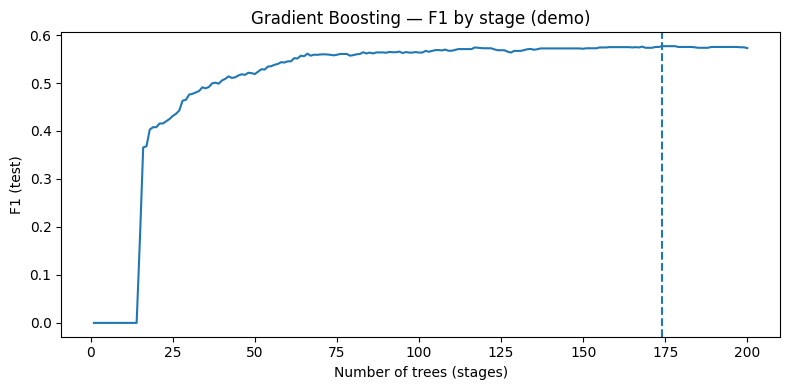

In [33]:
# BONUS: stage-by-stage curve for Gradient Boosting

pipe_gb.fit(X_train, y_train)

# Transform once, then use staged_predict on the underlying model
X_test_trans = pipe_gb.named_steps["preprocess"].transform(X_test)
gb_est = pipe_gb.named_steps["model"]

f1_by_stage = []
for y_pred_stage in gb_est.staged_predict(X_test_trans):
    f1_by_stage.append(f1_score(y_test, y_pred_stage))

best_stage = int(np.argmax(f1_by_stage)) + 1  # stages are 1-indexed for humans
print("Best stage (by test F1):", best_stage, "out of", len(f1_by_stage))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(f1_by_stage) + 1), f1_by_stage)
plt.axvline(best_stage, linestyle="--")
plt.xlabel("Number of trees (stages)")
plt.ylabel("F1 (test)")
plt.title("Gradient Boosting — F1 by stage (demo)")
plt.tight_layout()
plt.show()

## Wrap-up questions

1. Which methods seemed to help the most: bagging/RF or boosting?
2. Which metric should we care about most for churn: accuracy, recall, F1, ROC-AUC?
3. Why might impurity-based importance disagree with permutation importance?
4. If two features are strongly correlated, what happens to permutation importance?
